Used: https://quantum.cloud.ibm.com/docs/en/tutorials/hello-world

Figure 3: Circuit for Swap test: https://arxiv.org/pdf/2003.09187

For returning data: Qiskit provides 2 ways
- you can obtain a probability distribution for a set of qubits you choose to measure
- or you can obtain the expectation value of an observable

In our case, we wanna get the Fidelity.
$$
\text{Fidelity} = F
= \left|\langle \psi \mid \phi \rangle\right|^2
= 2P(0) - 1
$$

$$
\text{Expectation value} = \langle Z \rangle
= P(0) - P(1)
= 2P(0) - 1
= F
$$

So we wanna measure the q0 and get the expectation value, which is our fidelity.

Running on the simulator for now, so using FakeBelemV2 for now 

## Simplest setup: 2 train points, 1 test points, 1 dimension:

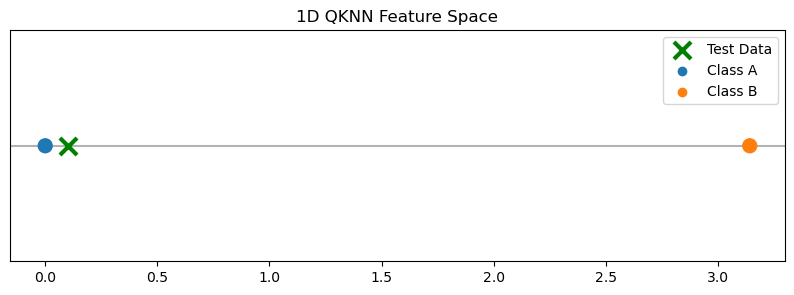

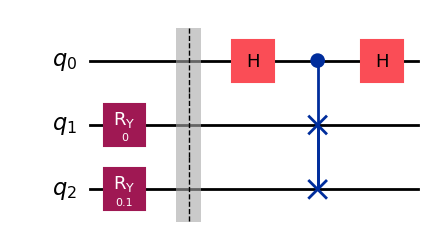

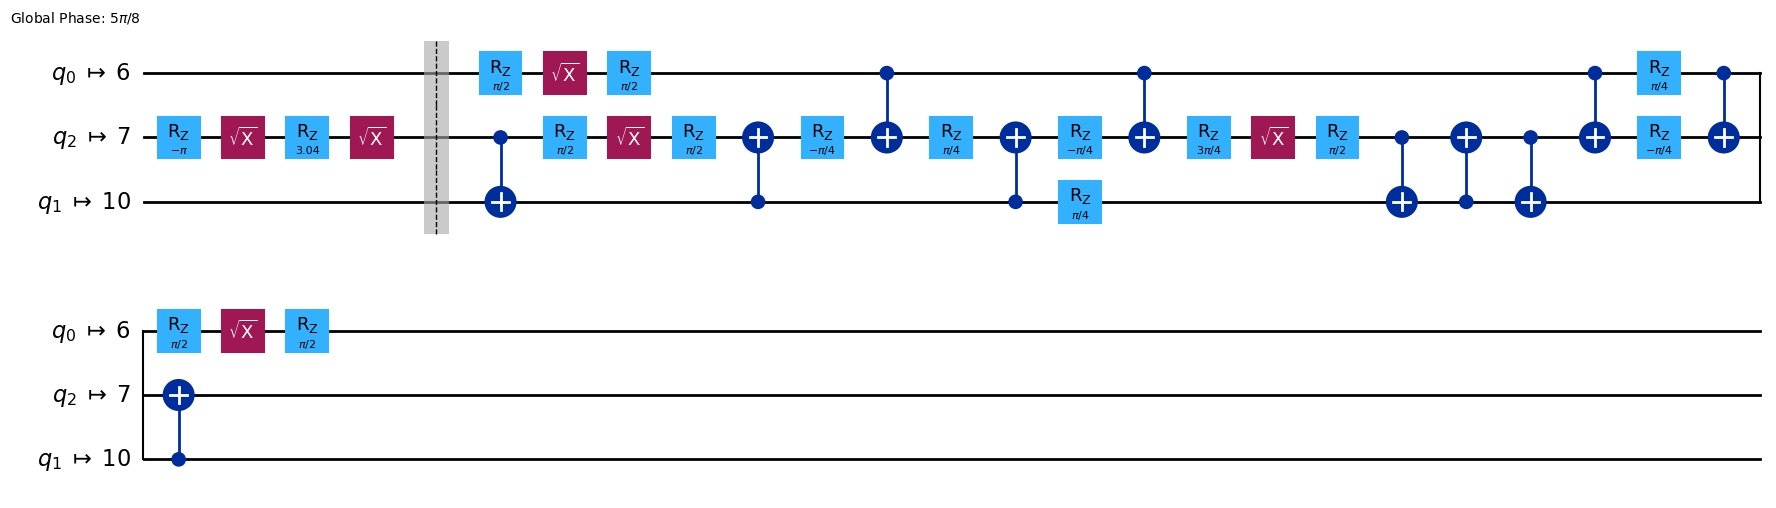

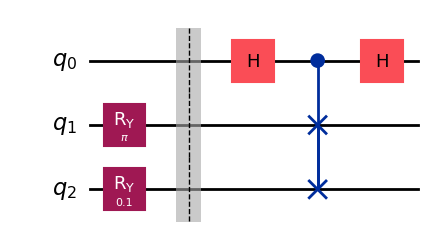

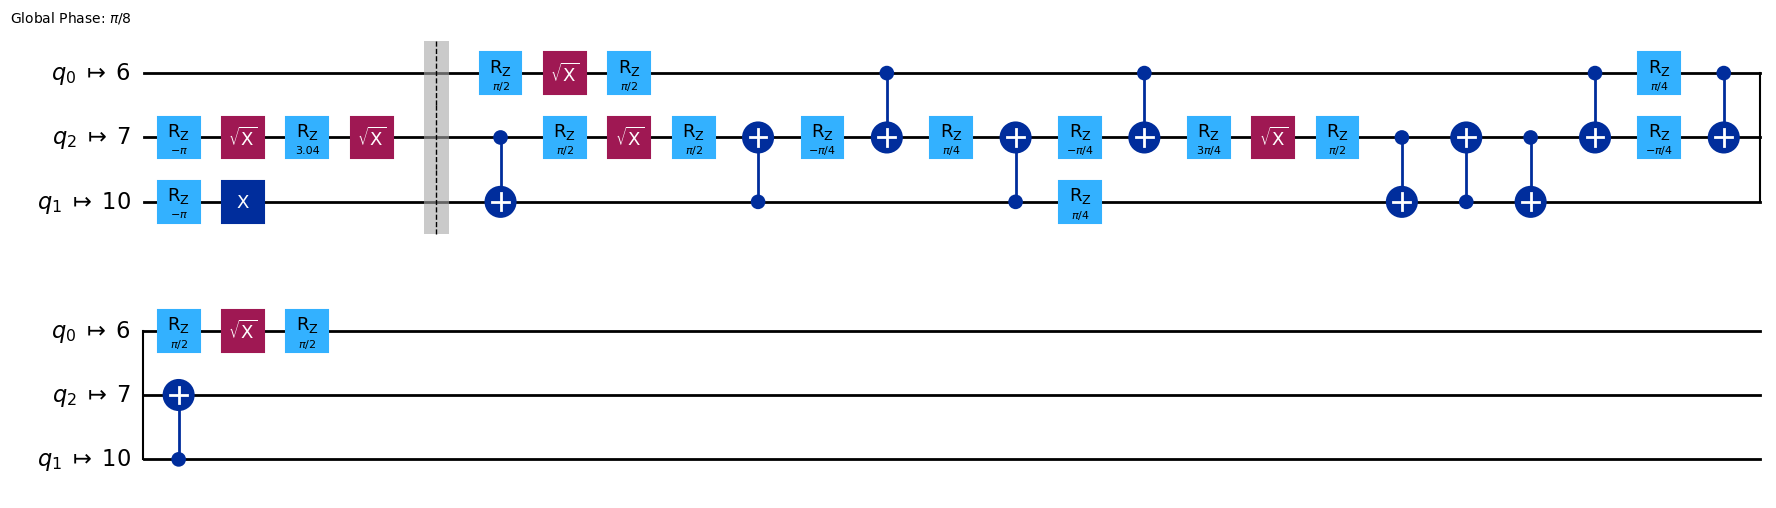

Fidelity Train 1 (Pi): 0.8736
Fidelity Train 2 (0):  0.0242
Prediction: Class A


In [28]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2 # 16 qubits (for more than 24 we need to install Qiskit air)
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister, qpy
from collections import Counter
from qiskit_aer import AerSimulator
from dataclasses import dataclass
from typing import List, Tuple
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

def visualize_1d(train_data, train_labels, test_data):
    unique_labels = sorted(list(set(train_labels)))
    cm = plt.get_cmap('tab10')
    color_map = {label: cm(i) for i, label in enumerate(unique_labels)}
    
    plt.figure(figsize=(10, 3))
    plt.axhline(0, color='black', alpha=0.3)
    
    train_x = [pt[0] for pt in train_data]
    test_x = [pt[0] for pt in test_data]
    
    plt.scatter(train_x, np.zeros_like(train_x), 
                c=[color_map[l] for l in train_labels], s=100, zorder=2)
    
    plt.scatter(test_x, np.zeros_like(test_x), 
                c='green', marker='x', s=150, linewidths=3, label='Test Data', zorder=3)
    
    for label, color in color_map.items():
        plt.scatter([], [], c=[color], label=label) 
    
    plt.title("1D QKNN Feature Space")
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.legend()
    plt.show()

def compute_fidelity_1d(train_val, test_val):
    qc = QuantumCircuit(3) # 1 for ancilla, 1 for 1 dimension train data, 1 for 1 dimension test data
    
    # 1. Encoding
    qc.ry(train_val, 1)
    qc.ry(test_val, 2)
    qc.barrier()
    
    # 2. SWAP Test
    qc.h(0)
    qc.cswap(0, 1, 2)
    qc.h(0)

    display(qc.draw("mpl"))

    isa = pm.run(qc)
    display(isa.draw("mpl"))
    obs = observable.apply_layout(isa.layout)
    estimator = EstimatorV2(backend)
    job = estimator.run([(isa, obs)], precision=0.01)
    result = job.result()

    return result[0].data.evs

train_points = [0, np.pi]
train_labels = ['Class A', 'Class B']
test_point = 0.1

visualize_1d([np.array([x]) for x in train_points], train_labels, [np.array([test_point])])

backend = FakeGuadalupeV2()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
observable = SparsePauliOp("IIZ") # Measure q0

fid1 = compute_fidelity_1d(train_points[0], test_point)
fid2 = compute_fidelity_1d(train_points[1], test_point)

print(f"Fidelity Train 1 (Pi): {fid1:.4f}")
print(f"Fidelity Train 2 (0):  {fid2:.4f}")

label = train_labels[0] if fid1 > fid2 else train_lables[1]
print(f"Prediction: {label}")

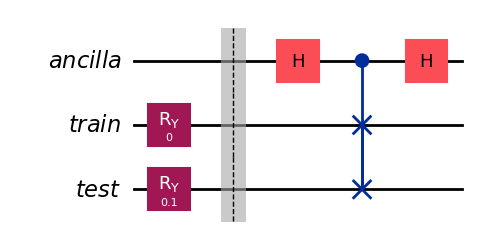

Fidelity(Test 0, Train 0 [Class A]): 0.8755
Fidelity(Test 0, Train 1 [Class B]): 0.0283
Test 0: top k nearest neighbors = ['Class A'] | Prediction: Class A ✅
OVERALL ACCURACY: 100.00%


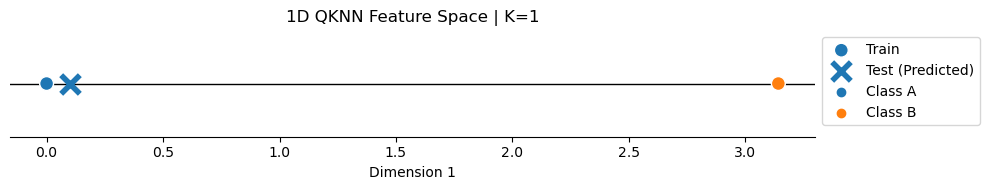

['Class A']

In [29]:
def visualize_data(train_data, train_labels, test_data, test_predictions, k_value):
    dims = len(train_data[0])
    is_1d = (dims == 1)

    train_x = [pt[0] for pt in train_data]
    test_x  = [pt[0] for pt in test_data]
    train_y = [0 if is_1d else pt[1] for pt in train_data]
    test_y  = [0 if is_1d else pt[1] for pt in test_data]

    if is_1d:
        plt.figure(figsize=(10, 2))
        plt.axhline(0, color='black', linewidth=1, zorder=1)
        plt.yticks([]); plt.ylim(-0.5, 0.5); plt.grid(False)
        for s in ['left', 'right', 'top']: plt.gca().spines[s].set_visible(False)
    else:
        plt.figure(figsize=(8, 6))
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylabel("Dimension 2")

    unique_labels = sorted(list(set(train_labels)))
    cm = plt.get_cmap('tab10')
    color_map = {l: cm(i) for i, l in enumerate(unique_labels)}

    plt.scatter(train_x, train_y, s=100, zorder=2, edgecolors='white',
                c=[color_map[l] for l in train_labels], label="Train")
    
    plt.scatter(test_x, test_y, s=180, zorder=3, marker='x', linewidths=4,
                c=[color_map[l] for l in test_predictions], label='Test (Predicted)')

    for label, color in color_map.items():
        plt.scatter([], [], c=[color], label=label)

    proj_text = " (Projection)" if dims > 2 else ""
    plt.title(f"{dims}D QKNN Feature Space{proj_text} | K={k_value}")
    plt.xlabel("Dimension 1")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

@dataclass
class ClassicalInput:
    train: List[np.ndarray]
    test: List[np.ndarray]

@dataclass
class QuantumInput:
    train: List[QuantumCircuit]
    test: List[QuantumCircuit]

QKNNInput = ClassicalInput | QuantumInput

def encode_classical_data(data: np.ndarray) -> QuantumCircuit:
    qc = QuantumCircuit(len(data))
    for i, val in enumerate(data):
        qc.ry(val, i)
    return qc

def get_initialization_circuits(qknn_input: QKNNInput, train_i: int, test_i: int) -> Tuple[QuantumCircuit, QuantumCircuit]:
    match qknn_input:
        case QuantumInput(train, test):
            return train[train_i], test[test_i]
        case ClassicalInput(train, test):
            return encode_classical_data(train[train_i]), encode_classical_data(test[test_i])

def compute_fidelity(train_init, test_init, show_circuit, backend):
    n_qubits = max(train_init.num_qubits, test_init.num_qubits)
    
    ancilla = QuantumRegister(1, name="ancilla")
    reg_a = QuantumRegister(n_qubits, name="train")
    reg_b = QuantumRegister(n_qubits, name="test")
    qc = QuantumCircuit(ancilla, reg_a, reg_b)

    # 1. State Preparation
    qc.compose(train_init, qubits=reg_a, inplace=True)
    qc.compose(test_init, qubits=reg_b, inplace=True)
    qc.barrier()

    # 2. SWAP Test
    qc.h(ancilla)
    for i in range(n_qubits):
        qc.cswap(ancilla[0], reg_a[i], reg_b[i])
    qc.h(ancilla)

    if show_circuit:
        display(qc.draw("mpl"))

    observable = SparsePauliOp("I" * (2 * n_qubits) + "Z") 
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(qc)
    isa_observable = observable.apply_layout(isa_circuit.layout)
    estimator = EstimatorV2(mode=backend)
    job = estimator.run([(isa_circuit, isa_observable)])
    result = job.result()[0].data.evs
    
    return float(result)

def qknn(qknn_input: QKNNInput, train_labels, K=1, test_labels=None, backend=FakeGuadalupeV2(), show_circuit=True):        
    predictions = []
    num_test = len(qknn_input.test)
    num_train = len(qknn_input.train)

    for i in range(num_test):
        fidelities = []
        for j in range(num_train):
            train_qc, test_qc = get_initialization_circuits(qknn_input, j, i)
            
            fid = compute_fidelity(train_qc, test_qc, show_circuit, backend)
            show_circuit = False 
            
            fidelities.append((fid, train_labels[j]))
            print(f"Fidelity(Test {i}, Train {j} [{train_labels[j]}]): {fid:.4f}")

        fidelities.sort(key=lambda x: x[0], reverse=True)
        top_k_labels = [label for fid, label in fidelities[:K]]
        prediction = Counter(top_k_labels).most_common(1)[0][0]
        predictions.append(prediction)
        
        status = ""
        if test_labels:
            if prediction == test_labels[i]:
                status = " ✅"
            else:
                status = f" - Actual: {test_labels[i]} ❌"
        
        print(f"Test {i}: top k nearest neighbors = {top_k_labels} | Prediction: {prediction}{status}")

    if test_labels:
        correct = sum(1 for p, a in zip(predictions, test_labels) if p == a)
        print(f"OVERALL ACCURACY: {(correct/num_test)*100:.2f}%")

    if isinstance(qknn_input, ClassicalInput):
        visualize_data(qknn_input.train, train_labels, qknn_input.test, predictions, K)

    return predictions

train_data = [np.array([0.0]), np.array([np.pi])] 
train_labels = ["Class A", "Class B"]
test_labels = ["Class A"]
test_data = [np.array([0.1])]

qknn(ClassicalInput(train=train_data, test=test_data), train_labels, test_labels=test_labels)

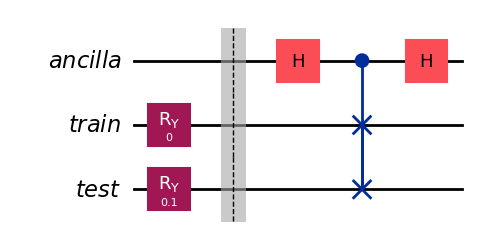

Fidelity(Test 0, Train 0 [Class A]): 0.8755
Fidelity(Test 0, Train 1 [Class B]): 0.0381
Test 0: top k nearest neighbors = ['Class A'] | Prediction: Class A


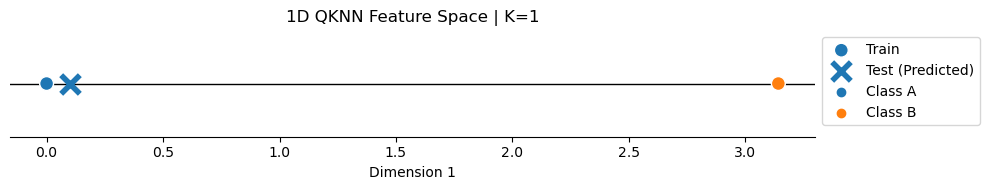

['Class A']

In [30]:
train_data_2d = [
    np.array([1, 1]),
    np.array([2, 3]),
    np.array([4, 4]),
    np.array([5, 5])
]
train_labels_2d = ["Class A", "Class A", "Class B", "Class B"]

test_data_2d = [np.array([3, 3]), np.array([4, 3])]

qknn(ClassicalInput(train=train_data, test=test_data), train_labels)

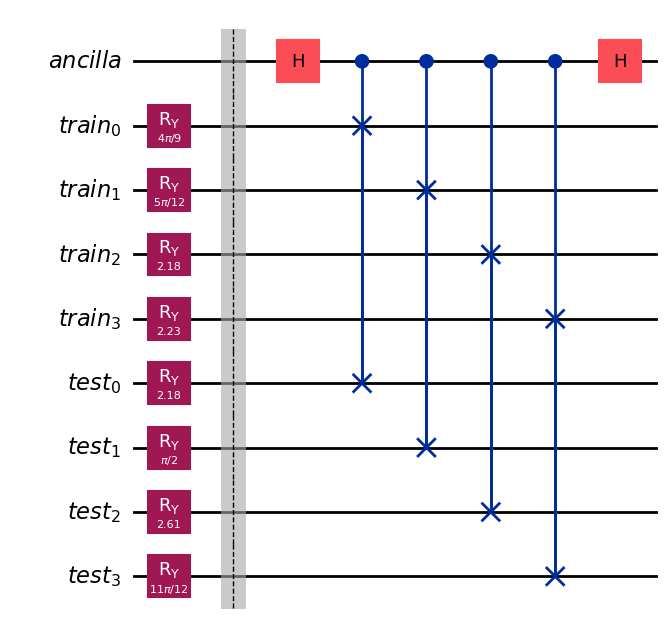

Fidelity(Test 0, Train 0 [virginica]): 0.4409
Fidelity(Test 0, Train 1 [setosa]): 0.0220
Fidelity(Test 0, Train 2 [versicolor]): 0.1450
Fidelity(Test 0, Train 3 [setosa]): 0.0225
Fidelity(Test 0, Train 4 [virginica]): 0.5264
Fidelity(Test 0, Train 5 [versicolor]): 0.4282
Fidelity(Test 0, Train 6 [virginica]): 0.3989
Fidelity(Test 0, Train 7 [setosa]): 0.0200
Fidelity(Test 0, Train 8 [versicolor]): 0.4380
Fidelity(Test 0, Train 9 [setosa]): 0.0552
Test 0: top k nearest neighbors = [np.str_('virginica'), np.str_('virginica'), np.str_('versicolor')] | Prediction: virginica ✅
Fidelity(Test 1, Train 0 [virginica]): 0.0747
Fidelity(Test 1, Train 1 [setosa]): 0.5864
Fidelity(Test 1, Train 2 [versicolor]): 0.1973
Fidelity(Test 1, Train 3 [setosa]): 0.5645
Fidelity(Test 1, Train 4 [virginica]): 0.0088
Fidelity(Test 1, Train 5 [versicolor]): 0.0894
Fidelity(Test 1, Train 6 [virginica]): 0.0703
Fidelity(Test 1, Train 7 [setosa]): 0.6221
Fidelity(Test 1, Train 8 [versicolor]): 0.0952
Fidelity(Test

KeyboardInterrupt: 

In [31]:
iris = load_iris()
X = iris.data  # The 4 features
y = iris.target # The labels (0, 1, 2)
target_names = iris.target_names # ['setosa', 'versicolor', 'virginica']

# 2. IMPORTANT: Normalize to [0, Pi] for Quantum RY gates
# If you don't scale, values like 7.9 will over-rotate the qubits!
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, train_size=10, test_size=3, random_state=42, stratify=y
)

train_labels = [target_names[i] for i in y_train]
test_labels_actual = [target_names[i] for i in y_test]

train_data = [np.array(pt) for pt in X_train]
test_data = [np.array(pt) for pt in X_test]

qknn(ClassicalInput(train=train_data, test=test_data), train_labels, test_labels=test_labels_actual, K=3)

In [32]:
def get_entanglement_states():
    abc_sep = QuantumCircuit(3)
    
    ab_c = QuantumCircuit(3)
    ab_c.h(0); ab_c.cx(0, 1)
    
    a_bc = QuantumCircuit(3)
    a_bc.h(1); a_bc.cx(1, 2)
    
    ac_b = QuantumCircuit(3)
    ac_b.h(0); ac_b.cx(0, 2)
    
    abc_ghz = QuantumCircuit(3)
    abc_ghz.h(0); abc_ghz.cx(0, 1); abc_ghz.cx(1, 2)
    
    return [abc_sep, ab_c, a_bc, ac_b, abc_ghz]

labels = ['A-B-C', 'AB-C', 'A-BC', 'AC-B', 'ABC']
circuits = get_entanglement_states()

qknn(
    qknn_input=QuantumInput(
    train=circuits,
    test=circuits
    ), 
    train_labels=labels, 
    test_labels=labels,
    show_circuit=False
)

Fidelity(Test 0, Train 0 [A-B-C]): 0.7021
Fidelity(Test 0, Train 1 [AB-C]): 0.3813
Fidelity(Test 0, Train 2 [A-BC]): 0.3896
Fidelity(Test 0, Train 3 [AC-B]): 0.3965
Fidelity(Test 0, Train 4 [ABC]): 0.3716
Test 0: top k nearest neighbors = ['A-B-C'] | Prediction: A-B-C ✅
Fidelity(Test 1, Train 0 [A-B-C]): 0.3623
Fidelity(Test 1, Train 1 [AB-C]): 0.6738
Fidelity(Test 1, Train 2 [A-BC]): 0.1646
Fidelity(Test 1, Train 3 [AC-B]): 0.1802


KeyboardInterrupt: 

In [38]:
# Load gate W and the class list
with open("W_gate list.qpy", "rb") as handle:
    qc_train = qpy.load(handle)

labels_train = np.load("Class list 2.npy")   

In [39]:
# Load gate V and entanglement class
with open("V_gate list.qpy", "rb") as handle:
    qc_test = qpy.load(handle)

labels_test = np.load("Class list test.npy")

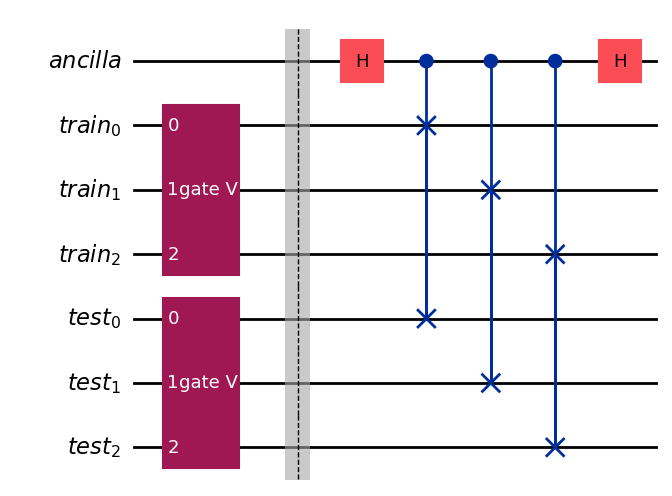

Fidelity(Test 0, Train 0 [0.0]): 0.0776
Fidelity(Test 0, Train 1 [1.0]): 0.1689
Fidelity(Test 0, Train 2 [0.0]): 0.0396
Fidelity(Test 0, Train 3 [1.0]): 0.1284
Fidelity(Test 0, Train 4 [1.0]): 0.0576
Fidelity(Test 0, Train 5 [1.0]): 0.1304
Fidelity(Test 0, Train 6 [0.0]): 0.2778
Fidelity(Test 0, Train 7 [0.0]): 0.0347


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [40]:
qknn(
    qknn_input=QuantumInput(
    train= qc_train,
    test = qc_test
    ), 
    train_labels=labels_train, 
    test_labels=labels_test,
    show_circuit=True
)